1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Recognized Equation: 10z-368


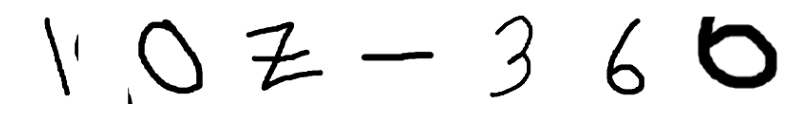

In [27]:
# without preprocessing

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("math_symbol_classifier2.h5")

# Define label-to-character mapping
label_map = {
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 
    5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 
    10: '+', 11: '*', 12: '-', 13: 'y', 14: 'z'
}

# Preprocess function
def preprocess_image(frame):
    resized_img = cv2.resize(frame, (100, 100))
    resized_img = resized_img / 255.0  # Normalize to [0,1]
    final_img = np.expand_dims(resized_img, axis=0)  # Shape: (1, 100, 100, 3)
    return final_img

# **STEP 1: Load and preprocess the image**
image_path = "Test_images_correct/eqn14.png"
frame = cv2.imread(image_path)

# Apply Canny Edge Detection to find character edges
edges = cv2.Canny(frame, 50, 150)

# Find contours (individual characters)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours left-to-right
bounding_boxes = [cv2.boundingRect(c) for c in contours]
bounding_boxes = sorted(bounding_boxes, key=lambda x: x[0])  # Sort by x-coordinate

# Recognized equation
recognized_equation = ""

# Store segmented character images for visualization
segmented_images = []


# STEP 2: Segment and classify each character
for (x, y, w, h) in bounding_boxes:
    # Add padding around the character
    pad = 20  # Adjust as needed
    x_start = max(x - pad, 0)
    y_start = max(y - pad, 0)
    x_end = min(x + w + pad, frame.shape[1])
    y_end = min(y + h + pad, frame.shape[0])

    # Extract character with padding
    char_img = frame[y_start:y_end, x_start:x_end]

    # Optional: Make the crop square by padding shorter side
    h_crop, w_crop = char_img.shape[:2]
    if h_crop != w_crop:
        size = max(h_crop, w_crop)
        square_img = np.ones((size, size, 3), dtype=np.uint8) * 255  # White background
        y_offset = (size - h_crop) // 2
        x_offset = (size - w_crop) // 2
        square_img[y_offset:y_offset+h_crop, x_offset:x_offset+w_crop] = char_img
        char_img = square_img

    # Resize to (100, 100) for model input
    char_img = cv2.resize(char_img, (100, 100))

    # Save for visualization
    segmented_images.append(char_img)

    # Preprocess and predict
    img = preprocess_image(char_img)
    predictions = model.predict(img)
    predicted_label = np.argmax(predictions)

    # Map to symbol
    predicted_symbol = label_map.get(predicted_label, "Unknown")
    recognized_equation += predicted_symbol


# **STEP 3: Output the recognized equation**
print(f"Recognized Equation: {recognized_equation}")

# **STEP 4: Display Segmented Images**
fig, axes = plt.subplots(1, len(segmented_images), figsize=(10, 3))
for ax, img in zip(axes, segmented_images):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for correct color display
    ax.axis('off')
plt.show()


In [28]:
import re

def fix_multiplication_symbols(extracted_text):
    """
    - Replaces standalone 'X' or 'x' with '*'
    - Converts '7X4' → '7*4' (Arithmetic multiplication)
    - Converts '4X' → '4*X' (Variable handling)
    """
    # Case 1: Replace 'X' or 'x' used as a multiplication sign between numbers
    fixed_text = re.sub(r'(\d)\s*[Xx]\s*(\d)', r'\1*\2', extracted_text)

    # Case 2: Replace standalone 'X' or 'x' (used for multiplication)
    fixed_text = re.sub(r'\b[Xx]\b', '*', fixed_text)

    # Case 3: Insert '*' between a number and any variable (a-z, A-Z)
    fixed_text = re.sub(r'(\d)([A-Za-z])', r'\1*\2', fixed_text)

    return fixed_text

In [29]:
corrected_equation = fix_multiplication_symbols(recognized_equation)
print("Corrected Equation:", corrected_equation)

Corrected Equation: 10*z-368


In [30]:
from sympy import sympify, solve, symbols

def process_equation(corrected_text):
    try:
        # Check if the equation contains a variable (A-Z, a-z)
        if any(char.isalpha() for char in corrected_text):
            # Extract the variable (assumes only one variable)
            variable_chars = [char for char in corrected_text if char.isalpha()]
            variable = symbols(variable_chars[0])  # Use the first detected variable

            # Convert to a sympy equation and solve (assume = 0)
            equation = sympify(corrected_text)  # Convert text to symbolic equation
            solution = solve(equation, variable)  # Solve for the variable

            return f"{variable} = {solution}"
        else:
            # No variable found → Directly evaluate the arithmetic expression
            return f"Result: {sympify(corrected_text)}"

    except Exception as e:
        return f"Error: {e}"


In [31]:
def handle_corrected_equation(corrected_equation):
    """
    Passes the corrected equation to process_equation() and returns the result.
    """
    result = process_equation(corrected_equation)
    return result



# Call the function
final_output = handle_corrected_equation(corrected_equation)

# Print the result
print("Final Output:", final_output)


Final Output: z = [184/5]
